## Checking linearity 

In both the Cox and the Poisson model

In [103]:
n <- 100
x <- seq(-1, 7, length.out = n)

y <- 2 + 3 * (x - 3) + (x - 3)^2 + rnorm(n, sd = 3)

dt <- tibble(x = x, y = y)

In [104]:
# The linear spline for x with a knot at 0

dt <- dt |>
    mutate(
        x01 = if_else(x > 0, x - 0, 0),
        x12 = if_else(x > 2, x - 2, 0)
    )

dt |> head()

x,y,x01,x12
<dbl>,<dbl>,<dbl>,<dbl>
-1.0000000,3.555976,0,0
-0.9191919,4.964273,0,0
-0.8383838,1.323256,0,0
-0.7575758,7.457306,0,0
-0.6767677,5.747320,0,0
-0.5959596,7.032778,0,0


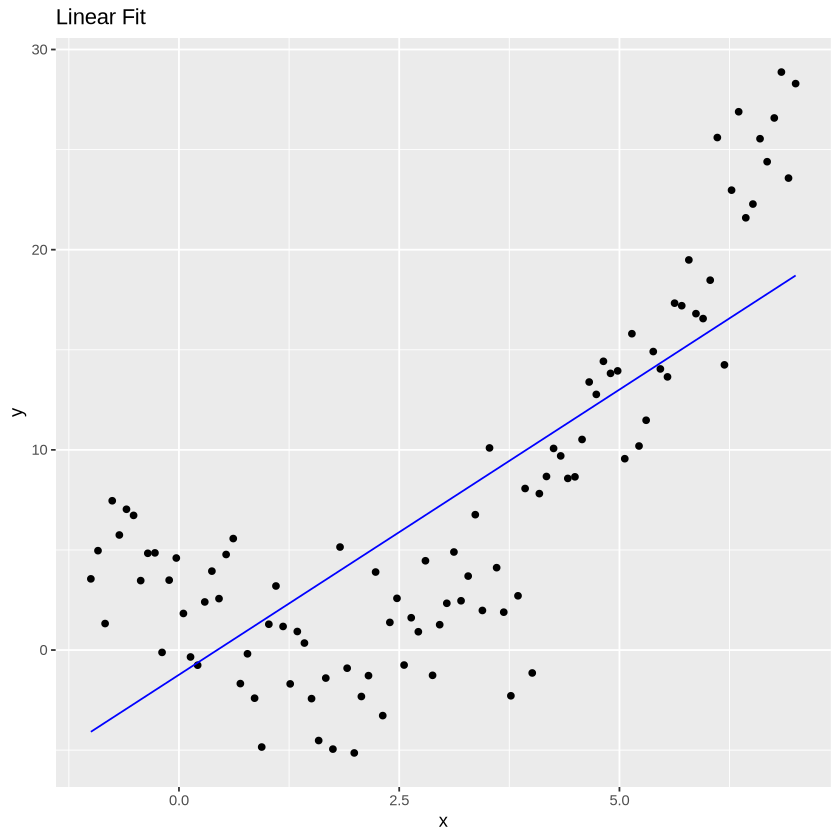

In [105]:
fit1 <- lm(y ~ x, data = dt)

# Plot the fitted line from the linear model

dt |> ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_line(aes(y = predict(fit1)), color = "blue") +
    labs(title = "Linear Fit")

In [106]:
fit_lspline <- lm(y ~ x + x01 + x12, data = dt)

fit_lspline |> summary()


Call:
lm(formula = y ~ x + x01 + x12, data = dt)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.1291 -1.7281  0.0947  1.8485  7.9176 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   3.2127     0.9082   3.537 0.000624 ***
x            -2.1457     1.9051  -1.126 0.262838    
x01          -1.1281     2.3244  -0.485 0.628562    
x12           8.9049     0.7674  11.605  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.976 on 96 degrees of freedom
Multiple R-squared:  0.8847,	Adjusted R-squared:  0.8811 
F-statistic: 245.5 on 3 and 96 DF,  p-value: < 2.2e-16


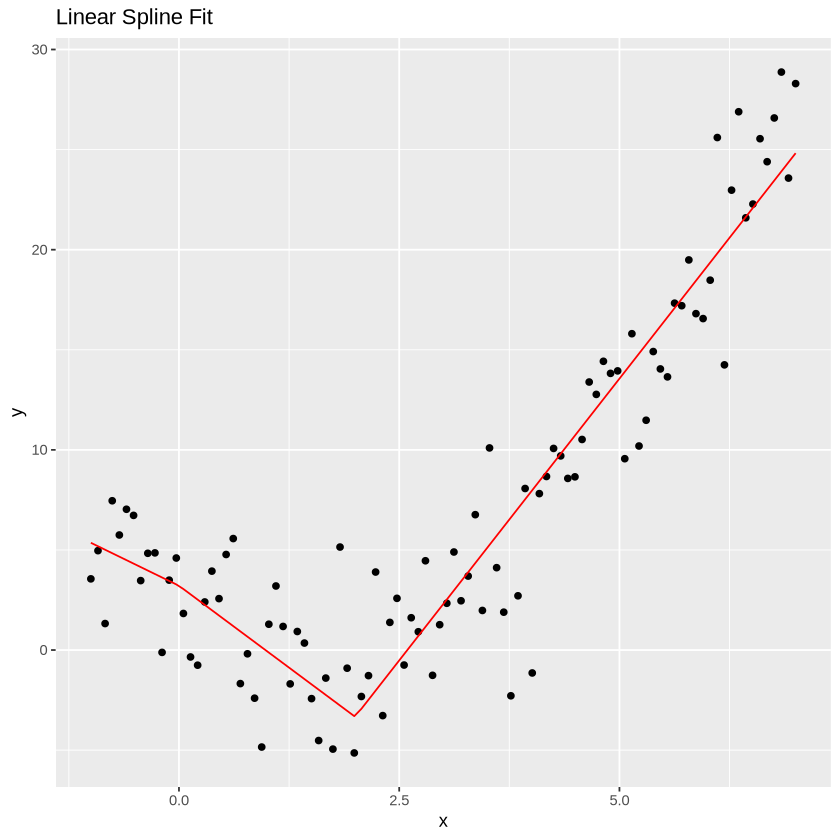

In [107]:
# Plot the fitted line from the linear spline model

dt |> ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_line(aes(y = predict(fit_lspline)), color = "red") +
    labs(title = "Linear Spline Fit")

In [108]:
library(lspline)

fit_lspline <- lm(y ~ lspline(x, c(0, 2)), data = dt)

fit_lspline |> summary()

ERROR: Error in library(lspline): there is no package called ‘lspline’
